# 룰베이스 vs Mask R-CNN 세그멘테이션 비교

`data/raw2`에서 `rule_based_raw2_sample.ipynb`와 **동일한 40장(seed=42)**에 대해, 세그멘테이션만 두 가지 방식으로 바꿔보고 `classify_shape()` 결과를 비교한다.

- **룰베이스**: `src/rule_based/shape_classifier.py`의 `get_mask()` (Otsu+Canny+GrabCut)
- **Mask R-CNN (dl1)**: `src/deep_learning/dl1_maskrcnn/segment.py`의 `get_mask_maskrcnn()` — COCO 사전학습 가중치, **우리 데이터로 학습 안 함(제로샷)**. cup/bottle/vase/wine glass/bowl 중 점수 높은 검출을 사용.

두 방식 다 `classify_shape()`는 그대로 재사용 — 마스크만 다른 방법으로 얻고, 판정 로직(폭 프로파일 → 4종 규칙)은 CLAUDE.md에 명시된 트랙 간 유일한 코드 공유 지점이다.

In [ ]:
import sys, os, glob, random, time
from collections import Counter

sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from rule_based.shape_classifier import get_mask, classify_shape, compute_width_profile, SHAPE_LABELS_KO
from deep_learning.dl1_maskrcnn import load_model, get_mask_maskrcnn


def imread_unicode(path):
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def safe_classify(mask):
    """mask가 None이거나 비어있으면(검출 실패) 판정 대신 명시적으로 표시한다."""
    if mask is None or not mask.any():
        return {"shape": "미검출", "width_profile": []}
    return classify_shape(mask)


RANDOM_SEED = 42
SAMPLES_PER_CLASS = 10
DATA_DIR = os.path.join("..", "data", "raw2")
CLASSES = ["straight", "taper_smooth", "taper_step", "mug"]

t0 = time.time()
mrcnn_model, device = load_model()
print(f"Mask R-CNN 로드 완료: device={device}, {time.time()-t0:.1f}s")

In [2]:
random.seed(RANDOM_SEED)

samples = {}
for cls in CLASSES:
    class_dir = os.path.join(DATA_DIR, cls)
    files = sorted(glob.glob(os.path.join(class_dir, "*.jpg")))
    samples[cls] = random.sample(files, min(SAMPLES_PER_CLASS, len(files)))
    print(f"{cls}: 전체 {len(files)}장 중 {len(samples[cls])}장 샘플링")

straight: 전체 126장 중 10장 샘플링
taper_smooth: 전체 101장 중 10장 샘플링
taper_step: 전체 109장 중 10장 샘플링
mug: 전체 109장 중 10장 샘플링


## 클래스별 원본 / 룰베이스 마스크 / Mask R-CNN 마스크 비교

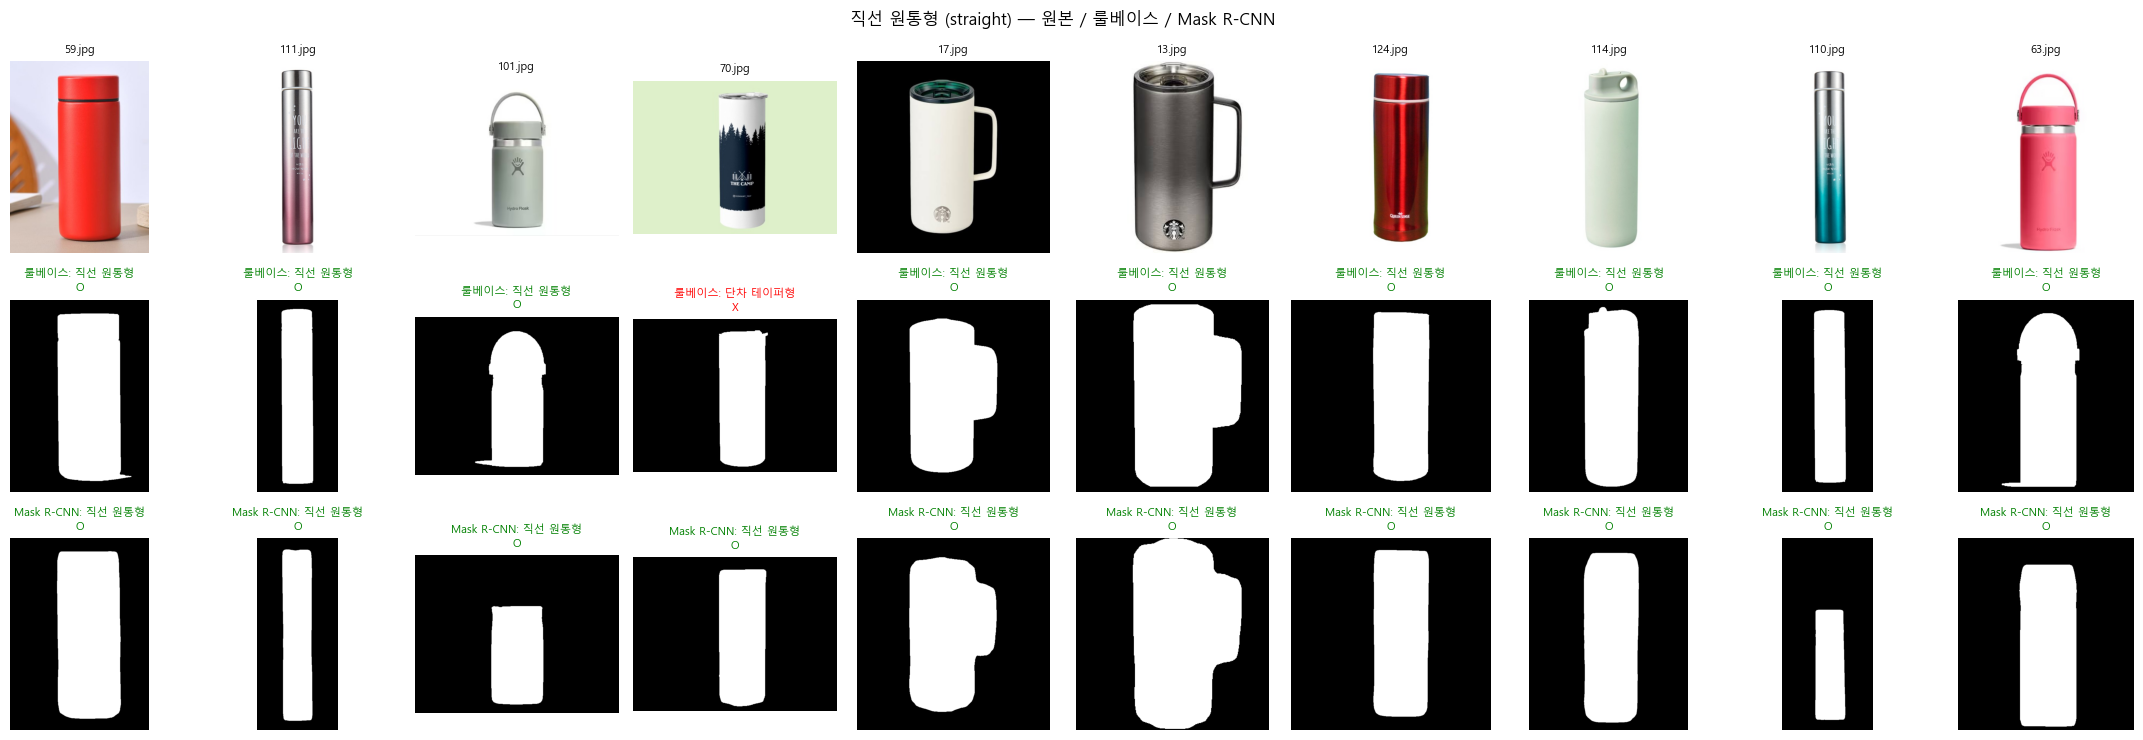

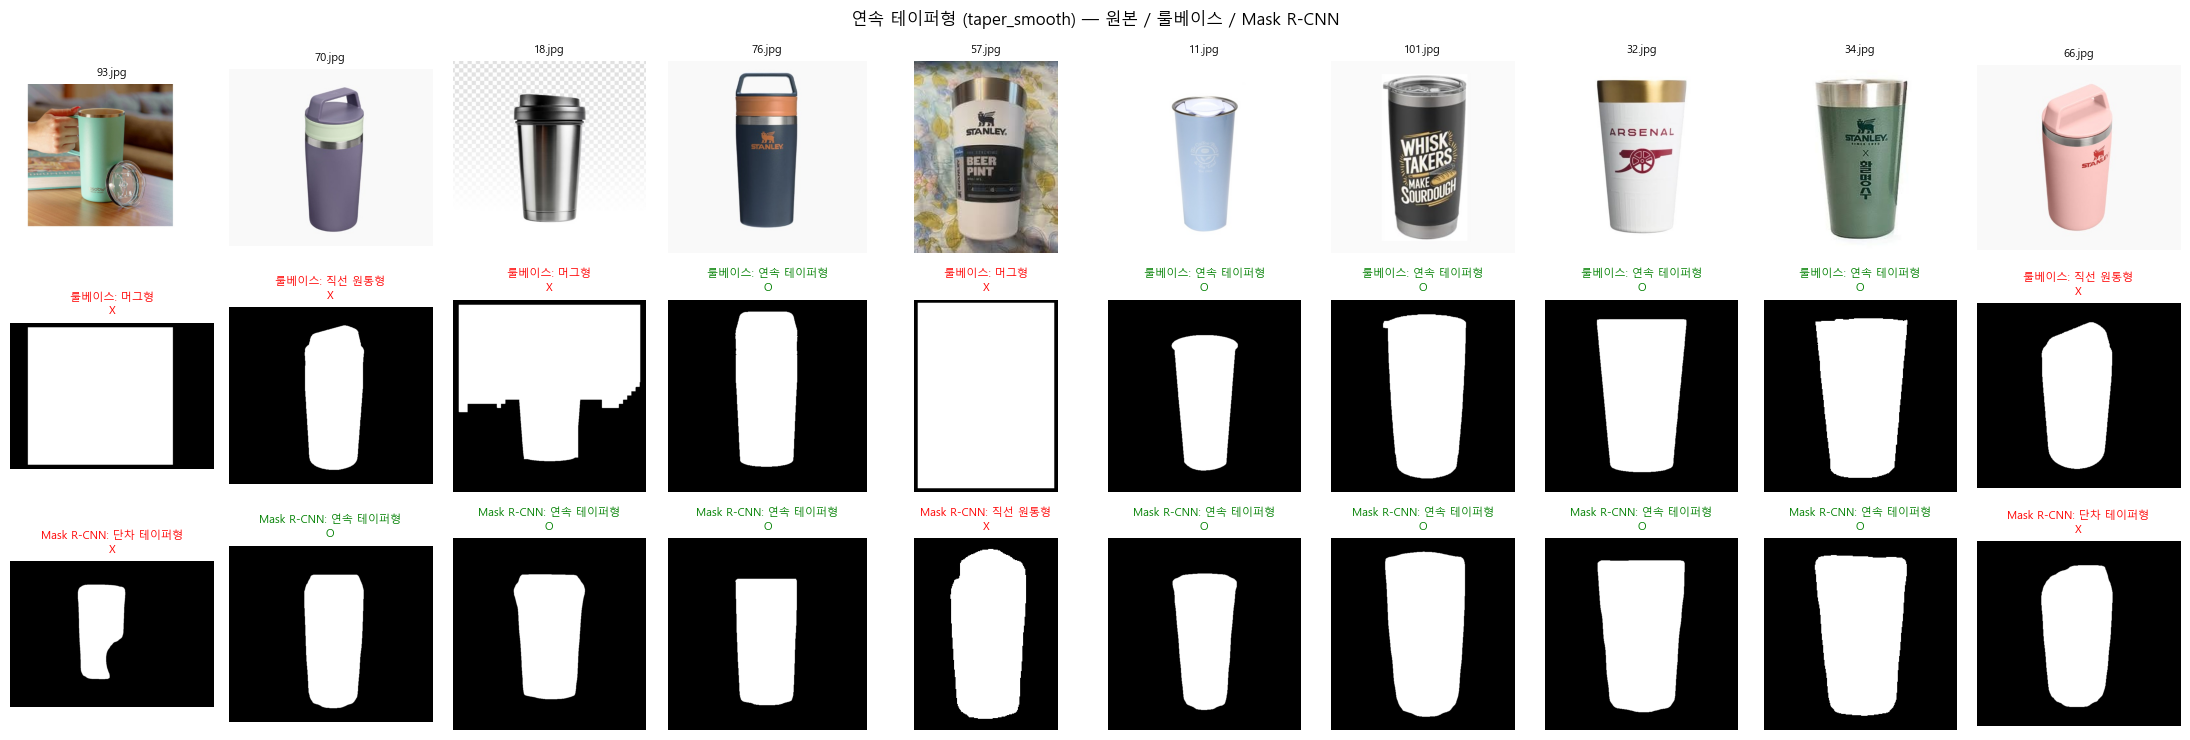

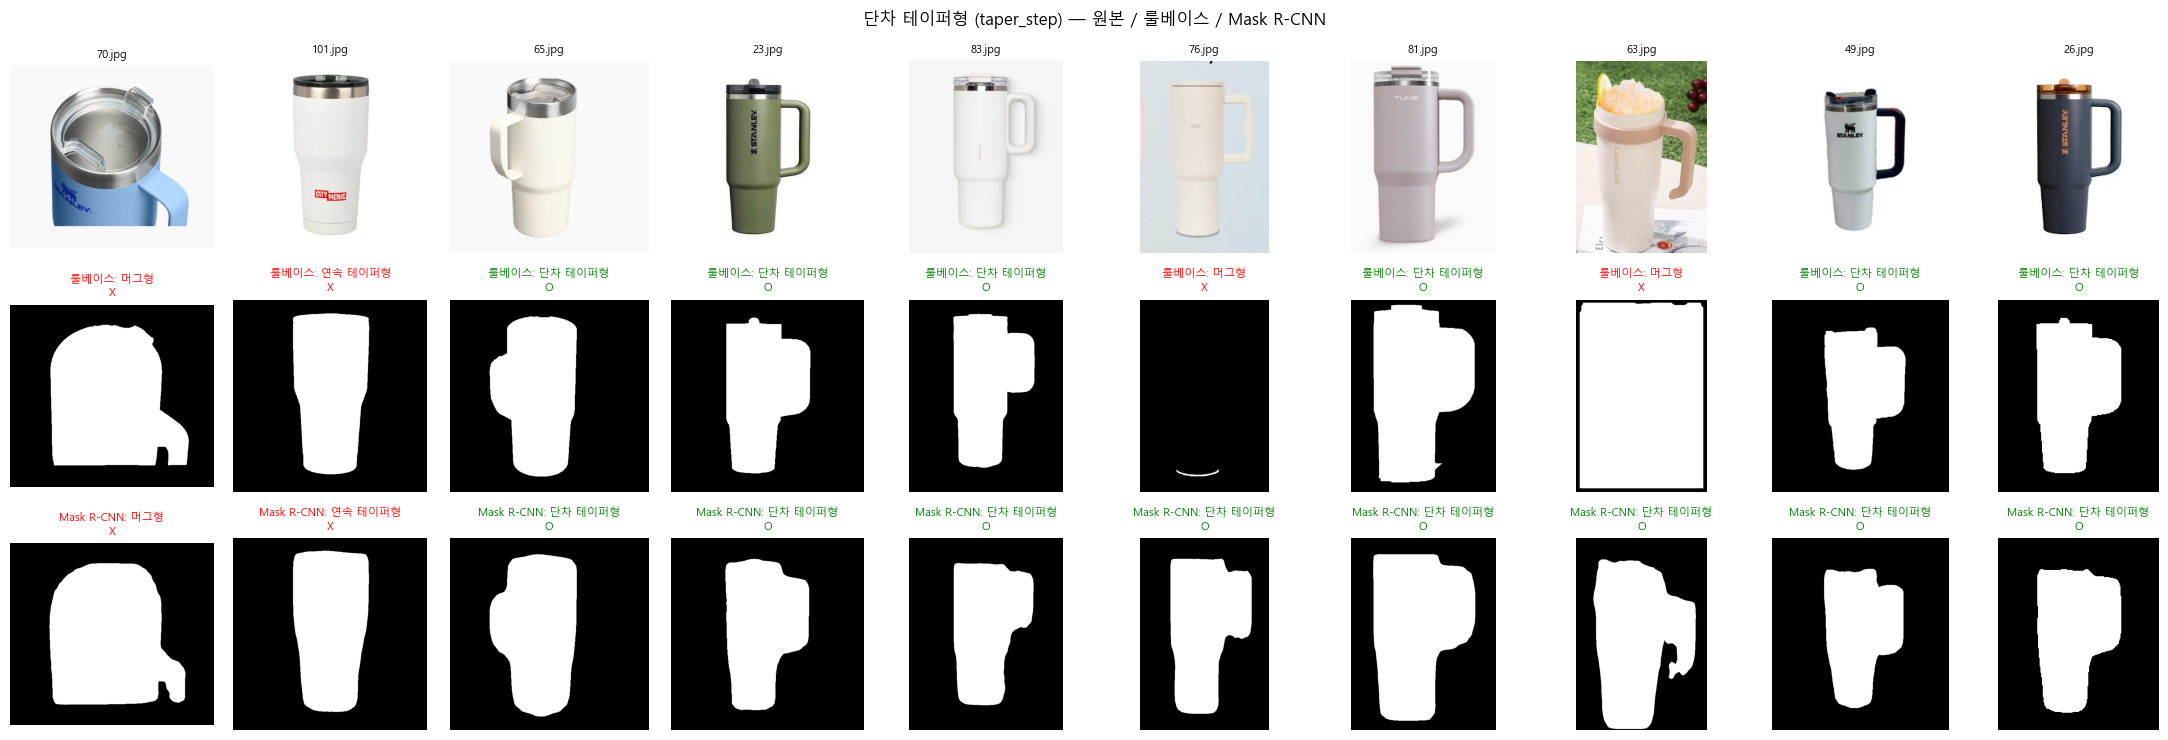

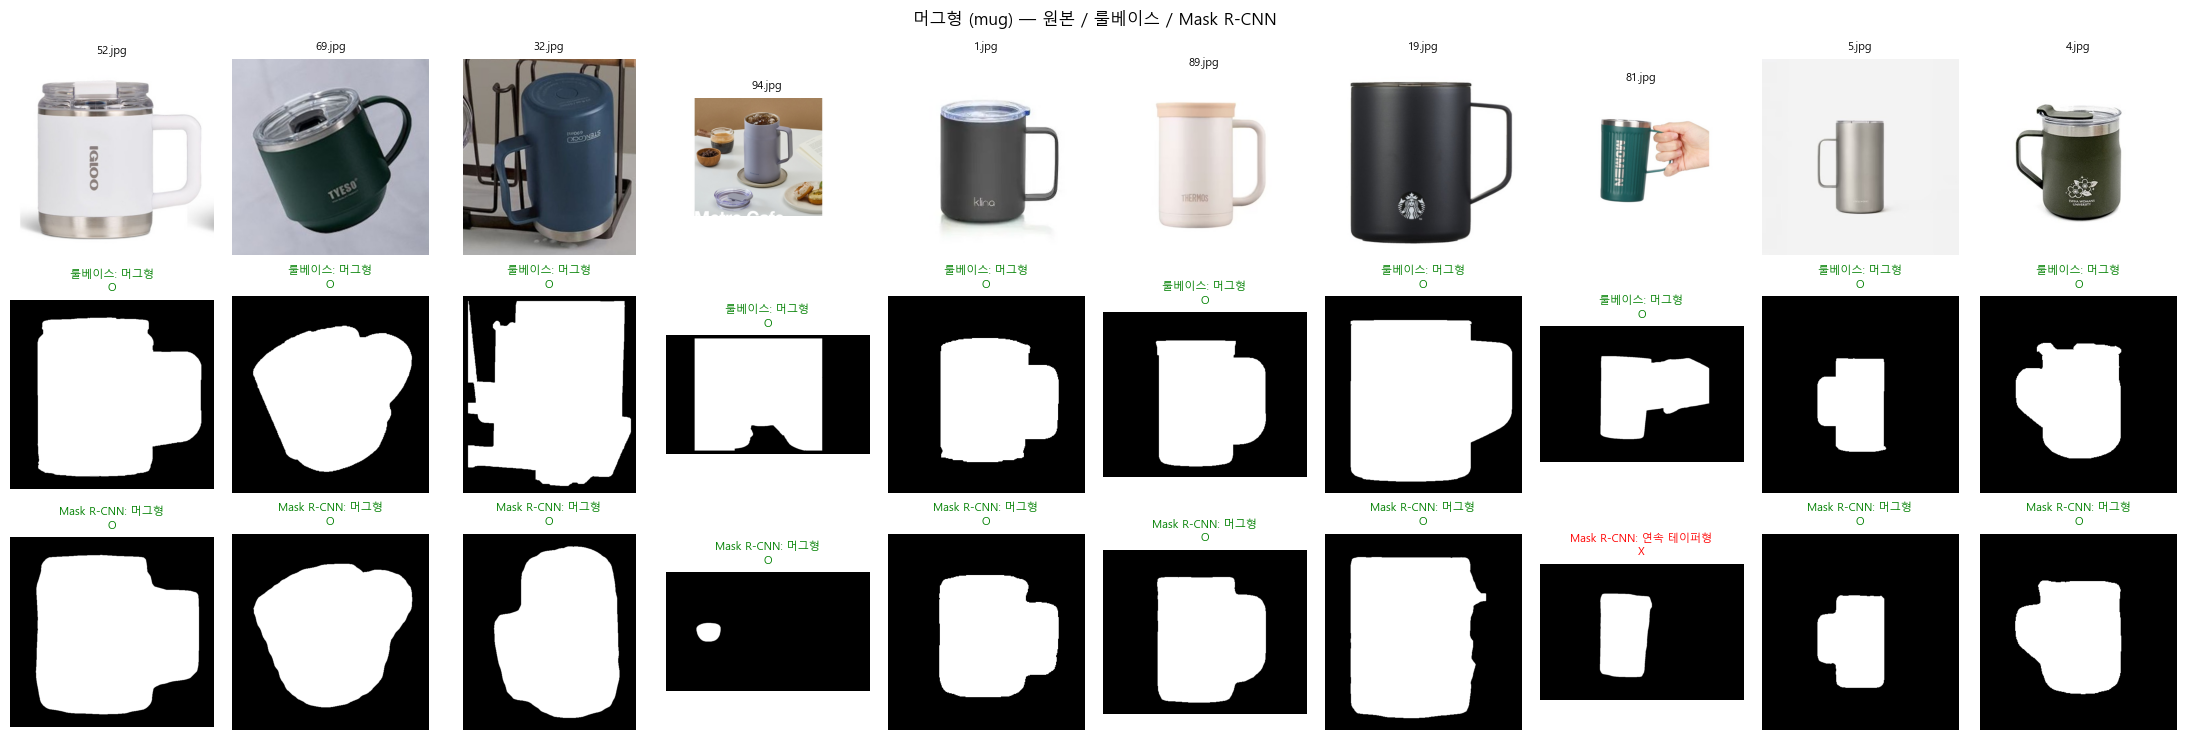

In [3]:
all_results = []
rule_times, mrcnn_times = [], []

for cls in CLASSES:
    paths = samples[cls]
    n = len(paths)
    fig, axes = plt.subplots(3, n, figsize=(2.2 * n, 7.5))

    for i, path in enumerate(paths):
        name = os.path.basename(path)
        image = imread_unicode(path)

        t0 = time.time()
        rule_mask = get_mask(image)
        rule_times.append(time.time() - t0)
        rule_result = safe_classify(rule_mask)

        t0 = time.time()
        mrcnn_mask = get_mask_maskrcnn(image, mrcnn_model, device)
        mrcnn_times.append(time.time() - t0)
        mrcnn_result = safe_classify(mrcnn_mask)

        rule_pred, mrcnn_pred = rule_result["shape"], mrcnn_result["shape"]
        rule_match, mrcnn_match = rule_pred == cls, mrcnn_pred == cls

        axes[0, i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(name, fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(rule_mask, cmap="gray")
        rule_label = SHAPE_LABELS_KO.get(rule_pred, rule_pred)
        axes[1, i].set_title(f"룰베이스: {rule_label}\n{'O' if rule_match else 'X'}", fontsize=8,
                              color=("green" if rule_match else "red"))
        axes[1, i].axis("off")

        axes[2, i].imshow(mrcnn_mask if mrcnn_mask is not None else np.zeros_like(rule_mask), cmap="gray")
        mrcnn_label = SHAPE_LABELS_KO.get(mrcnn_pred, mrcnn_pred)
        axes[2, i].set_title(f"Mask R-CNN: {mrcnn_label}\n{'O' if mrcnn_match else 'X'}", fontsize=8,
                              color=("green" if mrcnn_match else "red"))
        axes[2, i].axis("off")

        all_results.append({
            "folder_class": cls, "file": name,
            "rule_pred": rule_pred, "rule_match": rule_match,
            "mrcnn_pred": mrcnn_pred, "mrcnn_match": mrcnn_match,
        })

    fig.suptitle(f"{SHAPE_LABELS_KO[cls]} ({cls}) — 원본 / 룰베이스 / Mask R-CNN", fontsize=12)
    plt.tight_layout()
    plt.show()

## 정확도 비교 (참고용 — raw2 라벨 미검증)

In [4]:
header = f"{'클래스':14s} {'표본':>6s} {'룰베이스':>10s} {'Mask R-CNN':>12s}"
print(header)
print("-" * len(header))
for cls in CLASSES:
    cls_results = [r for r in all_results if r["folder_class"] == cls]
    total = len(cls_results)
    rule_matched = sum(r["rule_match"] for r in cls_results)
    mrcnn_matched = sum(r["mrcnn_match"] for r in cls_results)
    print(f"{cls:14s} {total:6d} {rule_matched}/{total} ({rule_matched/total*100:4.0f}%) "
          f"{mrcnn_matched}/{total} ({mrcnn_matched/total*100:4.0f}%)")

total = len(all_results)
rule_total_matched = sum(r["rule_match"] for r in all_results)
mrcnn_total_matched = sum(r["mrcnn_match"] for r in all_results)
print("-" * len(header))
print(f"{'합계':14s} {total:6d} {rule_total_matched}/{total} ({rule_total_matched/total*100:4.0f}%) "
      f"{mrcnn_total_matched}/{total} ({mrcnn_total_matched/total*100:4.0f}%)")

클래스                표본       룰베이스   Mask R-CNN
---------------------------------------------
straight           10 9/10 (  90%) 10/10 ( 100%)
taper_smooth       10 5/10 (  50%) 7/10 (  70%)
taper_step         10 6/10 (  60%) 8/10 (  80%)
mug                10 10/10 ( 100%) 9/10 (  90%)
---------------------------------------------
합계                 40 30/40 (  75%) 34/40 (  85%)


## Mask R-CNN 폴더 라벨별 실제 판정 분포 (혼동 확인용)

In [5]:
for cls in CLASSES:
    cls_results = [r for r in all_results if r["folder_class"] == cls]
    counts = Counter(r["mrcnn_pred"] for r in cls_results)
    breakdown = ", ".join(f"{SHAPE_LABELS_KO.get(k, k)}({k})={v}" for k, v in counts.most_common())
    print(f"{cls:14s}: {breakdown}")

straight      : 직선 원통형(straight)=10
taper_smooth  : 연속 테이퍼형(taper_smooth)=7, 단차 테이퍼형(taper_step)=2, 직선 원통형(straight)=1
taper_step    : 단차 테이퍼형(taper_step)=8, 머그형(mug)=1, 연속 테이퍼형(taper_smooth)=1
mug           : 머그형(mug)=9, 연속 테이퍼형(taper_smooth)=1


## 추론 속도 비교

In [6]:
print(f"룰베이스 get_mask()      평균 {np.mean(rule_times)*1000:6.1f}ms  (장당)")
print(f"Mask R-CNN ({device})   평균 {np.mean(mrcnn_times)*1000:6.1f}ms  (장당, 첫 장은 CUDA 워밍업 포함이라 더 느릴 수 있음)")

룰베이스 get_mask()      평균  503.0ms  (장당)
Mask R-CNN (cuda)   평균  149.7ms  (장당, 첫 장은 CUDA 워밍업 포함이라 더 느릴 수 있음)


**해석 시 주의**: raw2 라벨은 미검증 상태라 두 방법 모두 같은 조건에서 비교되므로(같은 40장, 같은 폴더 라벨) 상대 비교는 유효하지만, 절대 정확도 숫자는 참고용이다. 자세한 진단은 `docs/experiment-log.md`, `docs/troubleshooting.md` 참고.